# Clustering Analysis

**Authors:** Abderrahmane Salmi, Ricardo Talarico, Lorenzo Allegrini

In [441]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
from datetime import datetime
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [442]:
tracks_df = pd.read_csv("../datasets/tracks_cleaned.csv")
artists_df = pd.read_csv("../datasets/artists_cleaned.csv")

### Select which features will be used

In [443]:
# Print all feature names
tracks_original_features = tracks_df.columns.tolist()
print(tracks_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(tracks_original_features)}")

['swear_IT', 'swear_EN', 'year', 'n_tokens', 'tokens_per_sent', 'char_per_tok', 'lexical_density', 'avg_token_per_clause', 'bpm', 'centroid', 'rolloff', 'flux', 'flatness', 'spectral_complexity', 'pitch', 'loudness', 'album_type', 'explicit', 'popularity', 'duration_sec', 'swear_ratio', 'aggressiveness', 'relative_popularity', 'release_season', 'has_collaboration', 'song_age']

Total number of features: 26


In [444]:
# Print all feature names
artists_original_features = artists_df.columns.tolist()
print(artists_original_features)

# Print total number of features
print(f"\nTotal number of features: {len(artists_original_features)}")

['id_author', 'name', 'gender', 'birth_date', 'birth_place', 'nationality', 'description', 'active_start', 'active_end', 'province', 'region', 'country', 'latitude', 'longitude', 'starting_age', 'artist_age', 'birth_year', 'artist_collab_rate']

Total number of features: 18


In [445]:
print(tracks_df["duration_sec"].sample(10))

4898    3.741419
5939    3.422810
7378    3.817643
963     3.884521
3690    3.966347
7006    3.661900
4064    3.860395
8603    3.722885
4051    3.589226
5705    3.825437
Name: duration_sec, dtype: float64


## Features Selection

We tried to select features that capture different aspects, like: linguistic, audio, popularity, etc.

In [446]:
selected_features = [
    # linguistic / lyrics
    # 'n_tokens',
    # 'swear_IT',
    # 'lexical_density',

    # audio features
    # 'bpm',
    'centroid',
    'loudness',
    'spectral_complexity',
    # 'flux',
    'rolloff',

    # popularity
    'popularity',
    # 'relative_popularity',

    # time-related
    # 'season_autumn', 'season_spring', 'season_summer', 'season_winter',

    # engineered features
    # 'has_collaboration',
    'aggressiveness',
    # 'song_age',
    # 'duration_sec'
]

In [447]:
#Extract feature matrix
X = tracks_df[selected_features].copy()

## Preprocessing (Scaling & Normalization)

In [448]:
# Check for NaN values
print(X.isna().sum())

centroid               0
loudness               0
spectral_complexity    0
rolloff                0
popularity             0
aggressiveness         0
dtype: int64


**log1p transformation**: applying log to numeric skewed features

In [449]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric features for clustering
numeric_features = X.columns.tolist()  # X is our selected features for clustering

# Step 0: Filter out binary and one-hot encoded features (only keep features with >2 unique values)
continuous_features = [col for col in numeric_features if X[col].nunique() > 2]

# Step 1: Compute skewness
skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness of continuous features:\n", skewness)

# Step 2: Plot distribution of highly skewed features (optional)
high_skew = skewness[skewness > 2].index  # threshold for positive skew
# for col in high_skew:
#     plt.figure()
#     sns.histplot(X[col], kde=True)
#     plt.title(f'Distribution of {col} (skew={skewness[col]:.2f})')
#     plt.show()

# Step 3: Apply log1p transformation to highly skewed continuous features
for col in high_skew:
    # Only apply if all values are >= 0 (log1p cannot handle negative values)
    if (X[col] >= 0).all():
        X[col] = np.log1p(X[col])
    else:
        print(f"Skipping {col} because it has negative values.")

# Step 4: Verify the new skewness
new_skewness = X[continuous_features].skew().sort_values(ascending=False)
print("Skewness after log1p transformation:\n", new_skewness)

Skewness of continuous features:


 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64
Skewness after log1p transformation:
 popularity             0.260412
centroid               0.181541
spectral_complexity    0.099082
aggressiveness        -0.053941
rolloff               -0.060360
loudness              -0.153119
dtype: float64


**Normalization**: We tried to normalize using both z-score and min-max, to see which one works best for different algorithms.

In [450]:
# Scale the features (z-score)
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
X_zscore = std_scaler.fit_transform(X)

In [451]:
# Scale the features (Min-Max)
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()
X_minmax = minmax_scaler.fit_transform(X)

## K-Means

Train multiple KMeans models

In [452]:

from tqdm import tqdm


def run_kmeans_multiple(X, k_list, n_init=10, max_iter=300):
    """
    Train KMeans for multiple values of K.
    Returns:
        - list of KMeans models
        - SSE (inertia) list
        - Silhouette score list
    """
    kmeans_models = []
    sse_list = []
    silhouette_list = []

    for k in tqdm(k_list):
        kmeans = KMeans(n_clusters=k, n_init=n_init, max_iter=max_iter)
        kmeans.fit(X)

        kmeans_models.append(kmeans)
        sse_list.append(kmeans.inertia_)

        # Compute silhouette score if possible
        try:
            sil = silhouette_score(X, kmeans.labels_)
        except:
            sil = np.nan

        silhouette_list.append(sil)

        print(f"K={k}  | SSE={kmeans.inertia_:.2f} | Silhouette={sil:.4f}")

    return kmeans_models, sse_list, silhouette_list


Run KMeans for k = 2 to 16

In [453]:
k_list = list(range(2, 7))

kmeans_list, sse_list, silhouette_list = run_kmeans_multiple(
    X_minmax,
    k_list,
    n_init=10,
    max_iter=300
)


 20%|██        | 1/5 [00:05<00:21,  5.39s/it]

K=2  | SSE=1448.90 | Silhouette=0.2363


 40%|████      | 2/5 [00:09<00:14,  4.89s/it]

K=3  | SSE=1231.30 | Silhouette=0.2038


 60%|██████    | 3/5 [00:14<00:09,  4.60s/it]

K=4  | SSE=1095.56 | Silhouette=0.1806


 80%|████████  | 4/5 [00:18<00:04,  4.45s/it]

K=5  | SSE=985.71 | Silhouette=0.1848


100%|██████████| 5/5 [00:23<00:00,  4.65s/it]

K=6  | SSE=908.10 | Silhouette=0.1758


Plot SSE (Elbow Method)

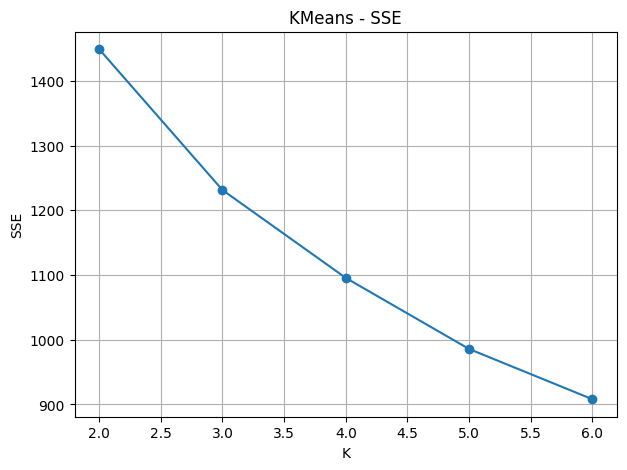

In [454]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.plot(k_list, sse_list, marker='o')
plt.xlabel('K')
plt.ylabel('SSE')
plt.title('KMeans - SSE')
plt.grid(True)
plt.show()


Plot Silhouette Scores

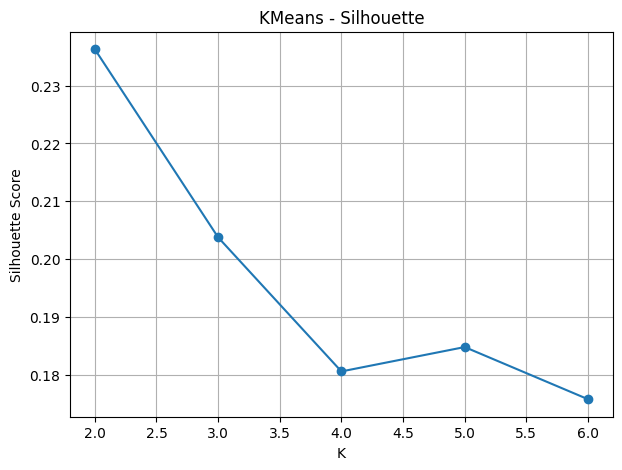

In [455]:
plt.figure(figsize=(7,5))
plt.plot(k_list, silhouette_list, marker='o')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.title('KMeans - Silhouette')
plt.grid(True)
plt.show()


Choose the best K after observing the graphs

In [456]:
best_k = 3
best_kmeans = kmeans_list[k_list.index(best_k)]
final_kmeans_clusters = best_kmeans.labels_

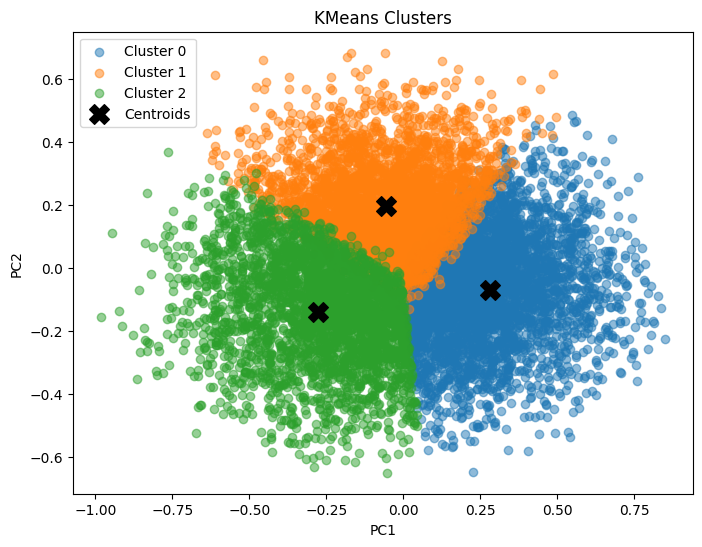

In [457]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Transform cluster centers into PCA space
centroids_pca = pca.transform(best_kmeans.cluster_centers_)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(best_kmeans.n_clusters):
    plt.scatter(
        X_pca[final_kmeans_clusters == cluster, 0],
        X_pca[final_kmeans_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

# Plot centroids
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    s=200,          # size
    c='black',      # color
    marker='X',     # marker shape
    label='Centroids'
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters')
plt.legend()
plt.show()


In [458]:
import pandas as pd
import numpy as np

# Get the centroid matrix (K x F)
centroids = best_kmeans.cluster_centers_

# Compute variance of each feature across centroids
feature_importance = centroids.var(axis=0)

# Convert to a sorted Series
feature_importance_series = pd.Series(
    feature_importance,
    index=X.columns
).sort_values(ascending=False)

print("Feature importance from centroid variance:\n")
print(feature_importance_series)


Feature importance from centroid variance:

popularity             0.015634
centroid               0.014513
aggressiveness         0.013473
spectral_complexity    0.011500
rolloff                0.010746
loudness               0.009203
dtype: float64


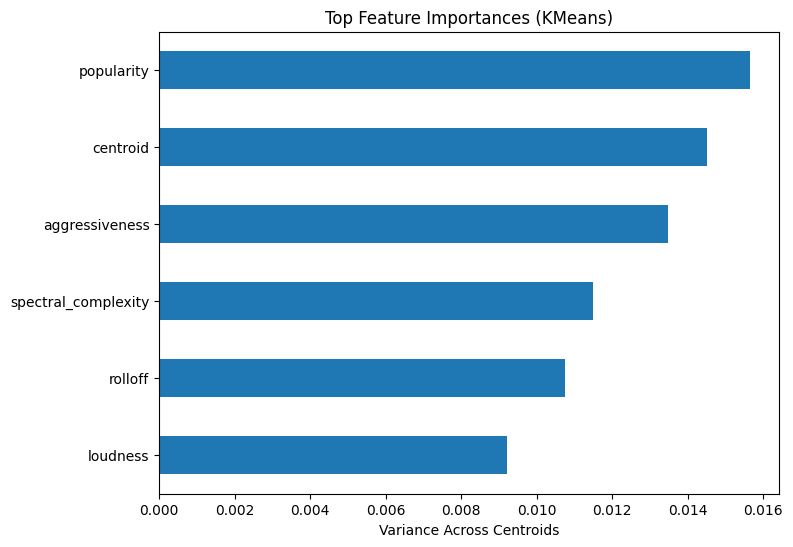

In [459]:
feature_importance_series.head(15).plot(kind='barh', figsize=(8,6))
plt.title("Top Feature Importances (KMeans)")
plt.xlabel("Variance Across Centroids")
plt.gca().invert_yaxis()
plt.show()


UMAP Cluster Visualization

c:\Users\Abdou\AppData\Local\Programs\Python\Python312\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


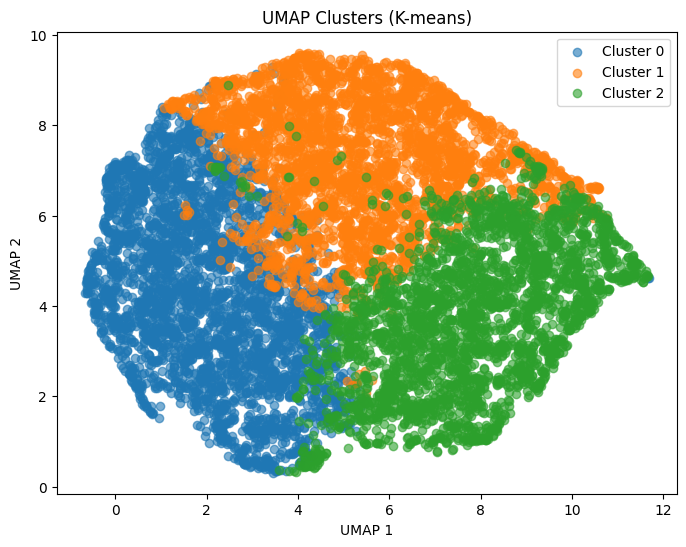

In [460]:
import umap.umap_ as umap
import matplotlib.pyplot as plt

# Run UMAP
reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(X_minmax)

# Plot
plt.figure(figsize=(8,6))
for cluster in range(best_kmeans.n_clusters):
    plt.scatter(
        X_umap[final_kmeans_clusters == cluster, 0],
        X_umap[final_kmeans_clusters == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.6
    )

plt.title("UMAP Clusters (K-means)")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.show()


Feature importance

t-SNE Cluster Visualization

In [461]:
# from sklearn.manifold import TSNE
# from sklearn.decomposition import PCA
# import matplotlib.pyplot as plt

# # Reduce dimensions before TSNE (recommended)
# pca_20 = PCA(n_components=min(20, X_minmax.shape[1]))
# X_pca20 = pca_20.fit_transform(X_minmax)

# # Run TSNE
# tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
# X_tsne = tsne.fit_transform(X_pca20)

# # Plot
# plt.figure(figsize=(8,6))
# for cluster in range(kmeans.n_clusters):
#     plt.scatter(
#         X_tsne[final_kmeans_clusters == cluster, 0],
#         X_tsne[final_kmeans_clusters == cluster, 1],
#         label=f'Cluster {cluster}',
#         alpha=0.6
#     )

# plt.title("t-SNE Clusters (K-means)")
# plt.xlabel("t-SNE 1")
# plt.ylabel("t-SNE 2")
# plt.legend()
# plt.show()


Analysis of Final K-Means

Cluster size distribution

Cluster sizes: [np.int64(3728), np.int64(3475), np.int64(3069)]


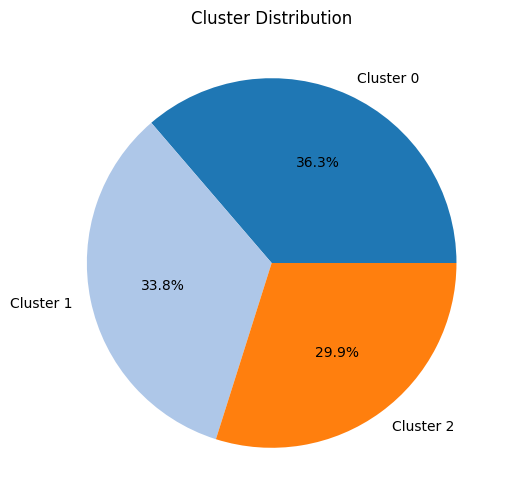

In [462]:
clusters = final_kmeans_clusters

n_clusters = len(np.unique(clusters))

# Count how many points per cluster
occ_list = [np.sum(clusters == k) for k in range(n_clusters)]

print("Cluster sizes:", occ_list)

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    occ_list,
    labels=[f"Cluster {k}" for k in range(n_clusters)],
    colors=sns.color_palette("tab20", n_clusters),
    autopct='%1.1f%%'
)
plt.title("Cluster Distribution")
plt.show()


Characterization of clusters

In [463]:
# Inspect the centroids

centroids = pd.DataFrame(
    best_kmeans.cluster_centers_,
    columns=X.columns
)
print(centroids)

   centroid  loudness  spectral_complexity   rolloff  popularity  \
0  0.666635  0.550328             0.634216  0.698272    0.266334   
1  0.459840  0.588256             0.506512  0.491362    0.529804   
2  0.380934  0.368453             0.371575  0.467342    0.262818   

   aggressiveness  
0        0.637495  
1        0.505405  
2        0.353410  


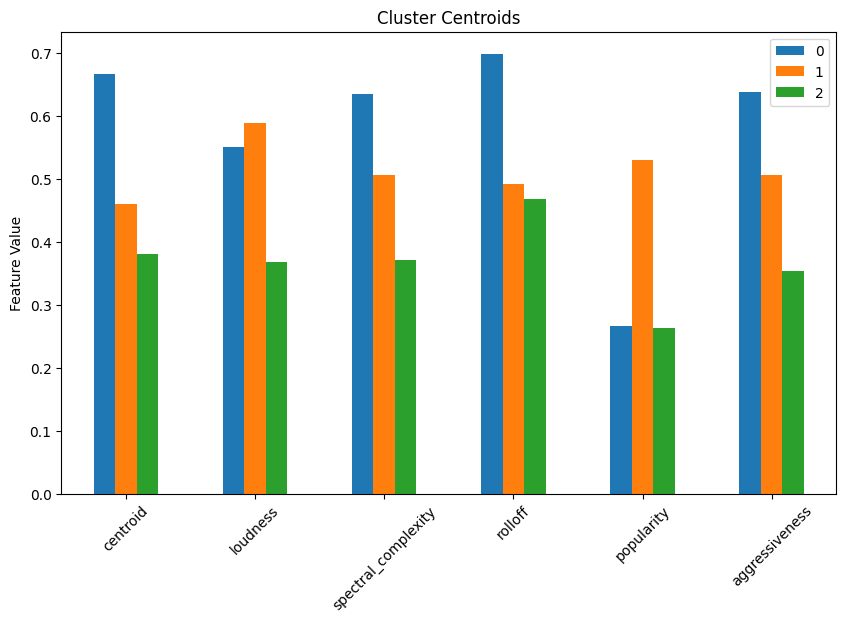

In [464]:
# Use barplot
centroids.T.plot(kind='bar', figsize=(10,6))
plt.title("Cluster Centroids")
plt.ylabel("Feature Value")
plt.xticks(rotation=45)
plt.show()

Feature importance across clusters

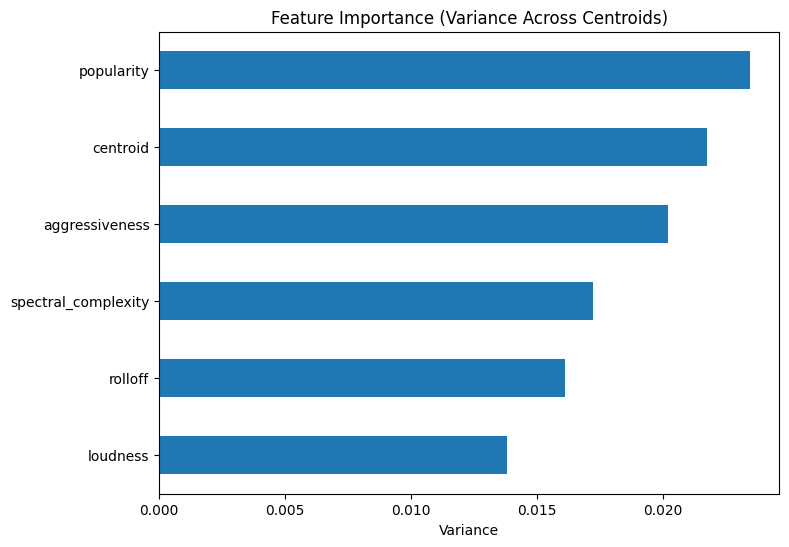

In [465]:
centroid_var = centroids.var(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8,6))
centroid_var.plot(kind='barh')
plt.title("Feature Importance (Variance Across Centroids)")
plt.xlabel("Variance")
plt.gca().invert_yaxis()
plt.show()


Compare feature distributions (cluster vs global)

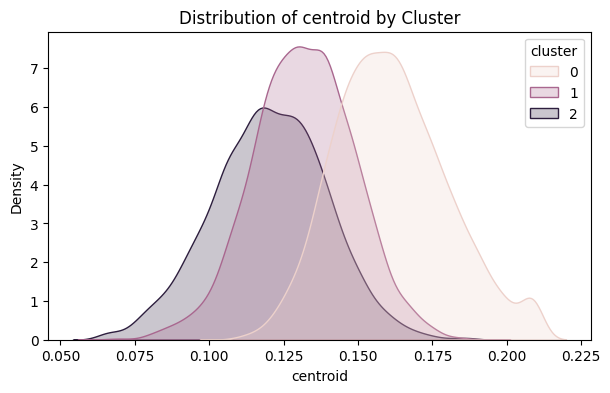

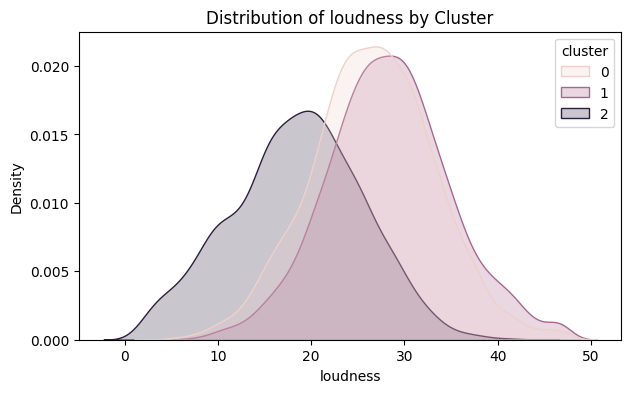

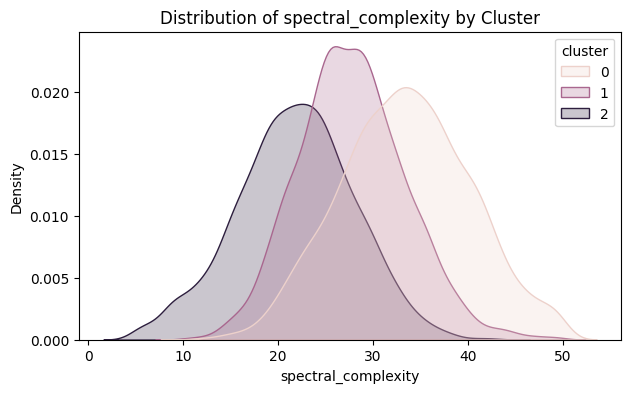

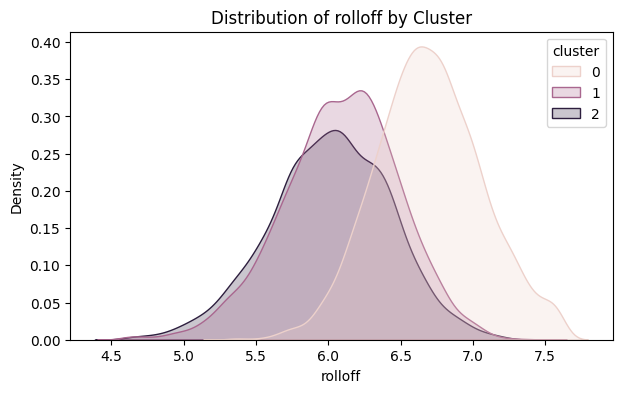

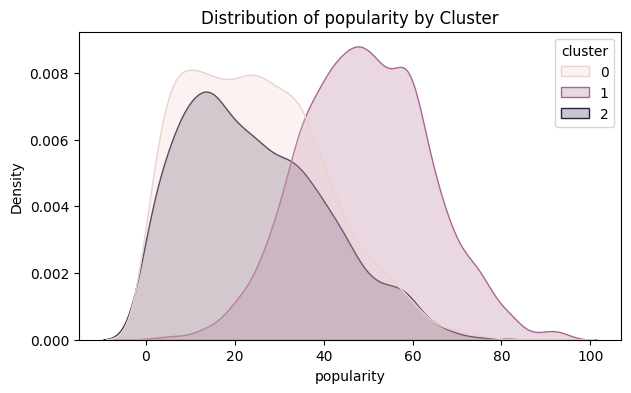

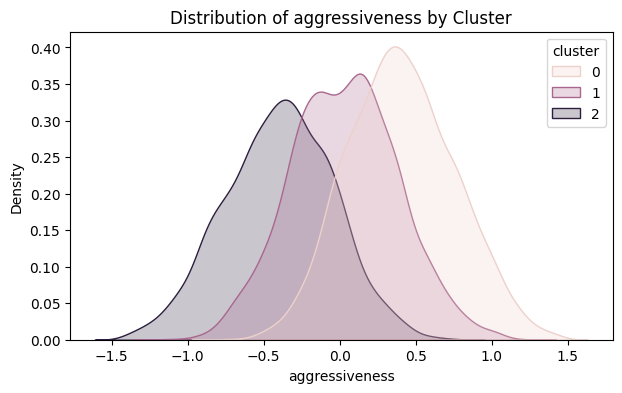

In [466]:
import seaborn as sns

df_clustered = tracks_df.copy()
df_clustered["cluster"] = final_kmeans_clusters

for col in X.columns:
    plt.figure(figsize=(7,4))
    sns.kdeplot(data=df_clustered, x=col, hue="cluster", fill=True)
    plt.title(f"Distribution of {col} by Cluster")
    plt.show()


Cluster means vs Dataset mean:

              centroid   loudness  spectral_complexity   rolloff  popularity  \
0             0.161186  26.592255            33.394572  6.692949   24.733101   
1             0.131595  28.290737            27.761143  6.085784   49.285755   
2             0.120231  18.469821            21.768710  6.012366   24.462366   
dataset_mean  0.138939  24.740082            28.015295  6.284206   32.958333   

              aggressiveness  
0                   0.403731  
1                   0.030792  
2                  -0.399543  
dataset_mean        0.037569  

Deviation from dataset mean:

         centroid  loudness  spectral_complexity   rolloff  popularity  \
cluster                                                                  
0        0.022247  1.852173             5.379277  0.408743   -8.225232   
1       -0.007344  3.550656            -0.254152 -0.198422   16.327422   
2       -0.018708 -6.270261            -6.246585 -0.271840   -8.495968   

         a

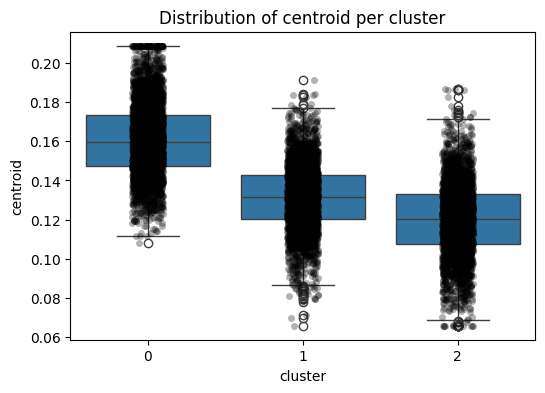

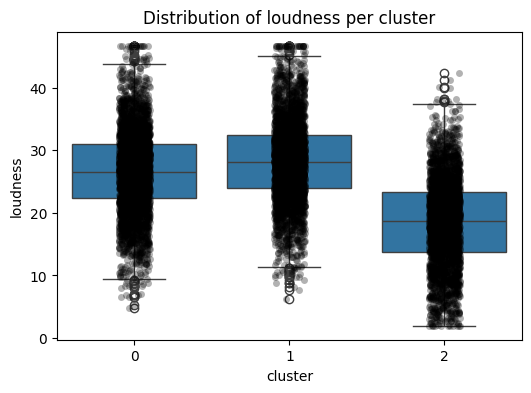

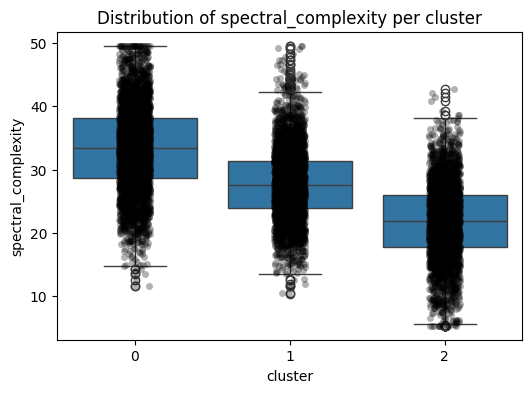

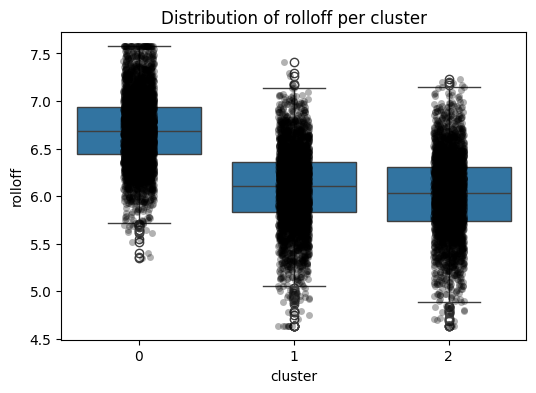

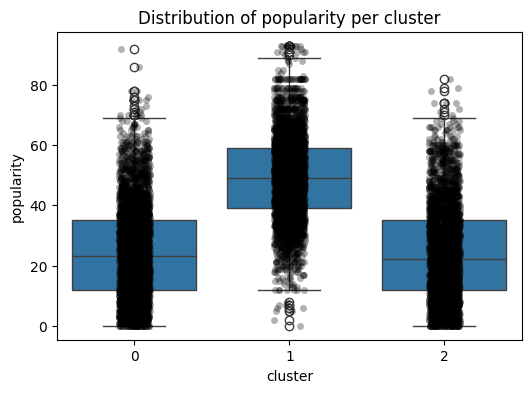

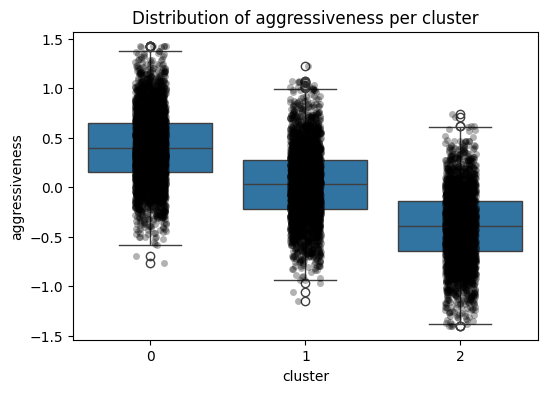

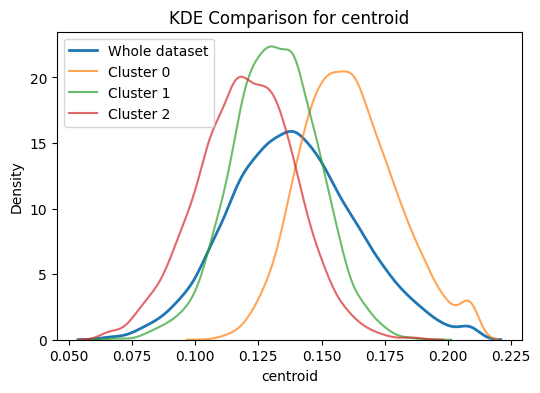

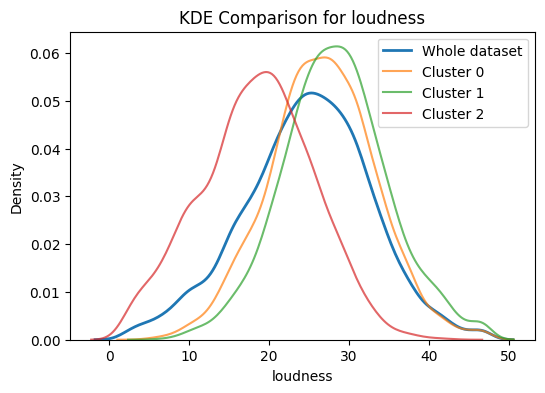

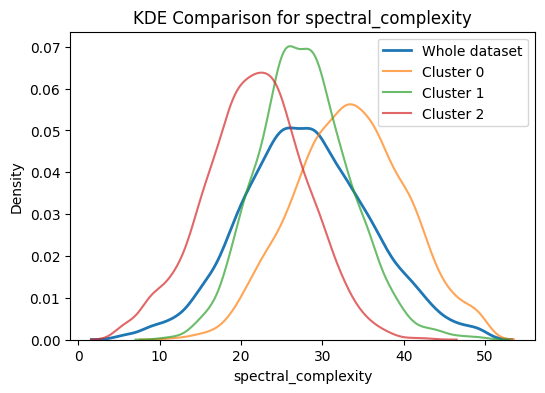

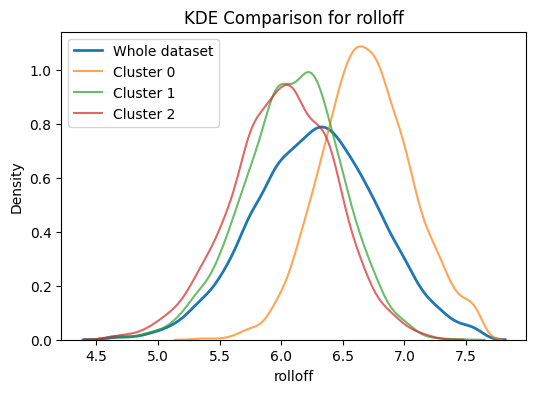

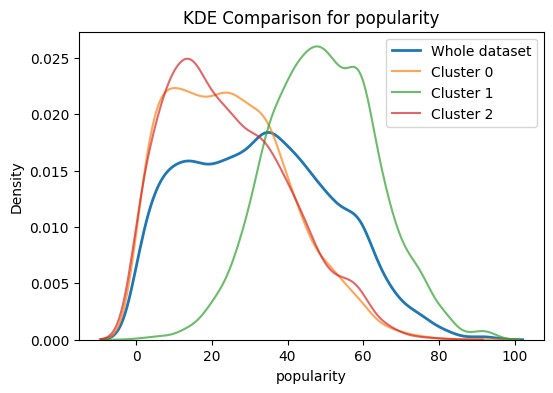

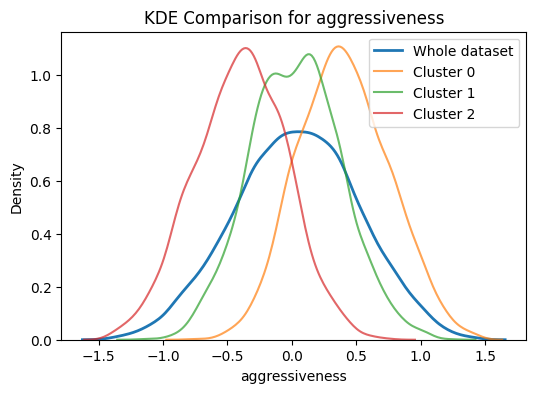

In [467]:
import pandas as pd
import numpy as np

# Create a dataframe with features + cluster labels
X_plot = X.copy()
X_plot['cluster'] = final_kmeans_clusters

# Compute cluster means and dataset mean
cluster_means = X_plot.groupby('cluster').mean()
dataset_mean = X.mean().to_frame().T
dataset_mean.index = ['dataset_mean']

# Combine with concat
summary = pd.concat([cluster_means, dataset_mean])

print("Cluster means vs Dataset mean:\n")
print(summary)

# Deviation from dataset mean
deviation = cluster_means - X.mean()
print("\nDeviation from dataset mean:\n")
print(deviation)

# Plot distributions with boxplots
import seaborn as sns
import matplotlib.pyplot as plt

for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=X_plot, x='cluster', y=col)
    sns.stripplot(data=X_plot, x='cluster', y=col, color='black', alpha=0.3)
    plt.title(f'Distribution of {col} per cluster')
    plt.show()

# KDE plots: cluster vs whole dataset
for col in X.columns:
    plt.figure(figsize=(6,4))
    sns.kdeplot(X[col], label='Whole dataset', linewidth=2)
    for cluster in np.unique(final_kmeans_clusters):
        sns.kdeplot(
            X_plot[X_plot.cluster == cluster][col],
            label=f'Cluster {cluster}',
            alpha=0.7
        )
    plt.title(f'KDE Comparison for {col}')
    plt.legend()
    plt.show()


Pairplot

In [468]:
# tracks_clusters = tracks_df.copy()
# tracks_clusters['cluster'] = clusters

In [469]:
# pairplot_features = [
#     'has_collaboration',
#     'n_tokens', 
#     'centroid', 
#     'popularity', 
#     'swear_ratio',  
#     'aggressiveness',
#     'cluster'
# ]

# sns.pairplot(
#     tracks_clusters[pairplot_features],
#     hue="cluster",
#     palette=sns.color_palette("tab20", n_clusters)
# )
# plt.show()


PCA in 3D

In [470]:
# from sklearn.decomposition import PCA
# from mpl_toolkits.mplot3d import Axes3D

# pca = PCA(n_components=3)
# X_pca3 = pca.fit_transform(X_zscore)

# fig = plt.figure(figsize=(10,7))
# ax = fig.add_subplot(111, projection='3d')

# for k in range(n_clusters):
#     ax.scatter(
#         X_pca3[clusters == k, 0],
#         X_pca3[clusters == k, 1],
#         X_pca3[clusters == k, 2],
#         s=15,
#         alpha=0.6,
#         label=f"Cluster {k}"
#     )

# ax.set_title("KMeans Clusters (3D PCA)")
# ax.set_xlabel("PC1")
# ax.set_ylabel("PC2")
# ax.set_zlabel("PC3")
# ax.legend()
# plt.show()


TODO: old code: delete later

In [471]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters_zscore = kmeans.fit_predict(X_zscore)

In [472]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans_clusters_minmax = kmeans.fit_predict(X_minmax)

### Visualization

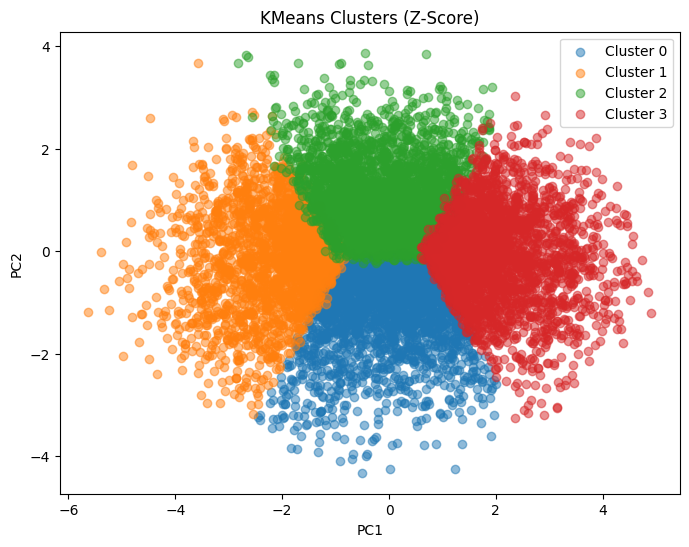

In [473]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_zscore)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[clusters_zscore == cluster, 0],
        X_pca[clusters_zscore == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (Z-Score)')
plt.legend()
plt.show()


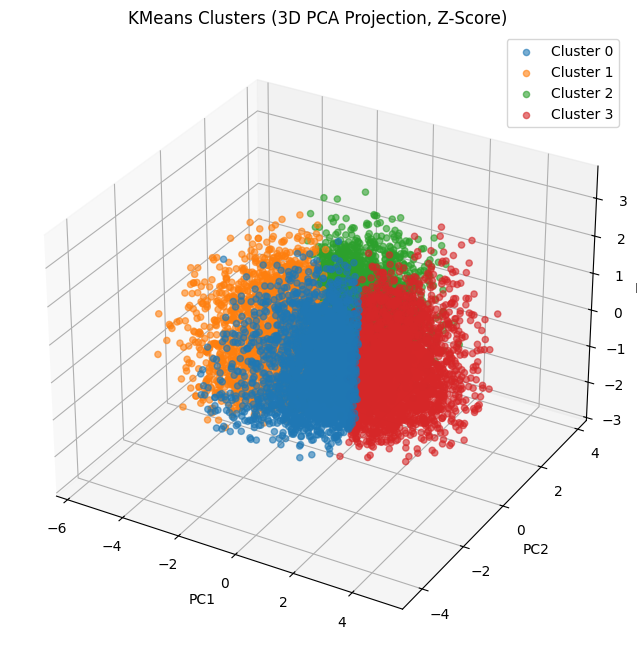

In [474]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # required for 3D projection

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_zscore)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[clusters_zscore == cluster, 0],
        X_pca_3d[clusters_zscore == cluster, 1],
        X_pca_3d[clusters_zscore == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, Z-Score)')
ax.legend()

plt.show()


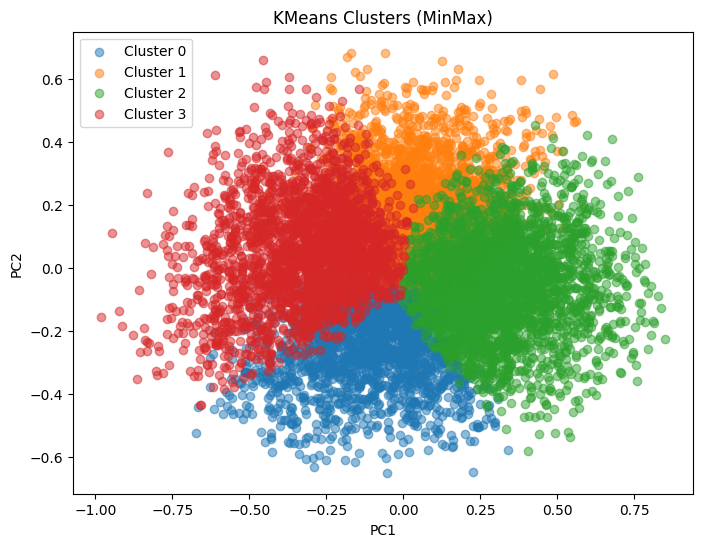

In [475]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# PCA to 2 dimensions
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_minmax)

# Plot clusters
plt.figure(figsize=(8,6))
for cluster in range(kmeans.n_clusters):
    plt.scatter(
        X_pca[kmeans_clusters_minmax == cluster, 0],
        X_pca[kmeans_clusters_minmax == cluster, 1],
        label=f'Cluster {cluster}',
        alpha=0.5
    )

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('KMeans Clusters (MinMax)')
plt.legend()
plt.show()


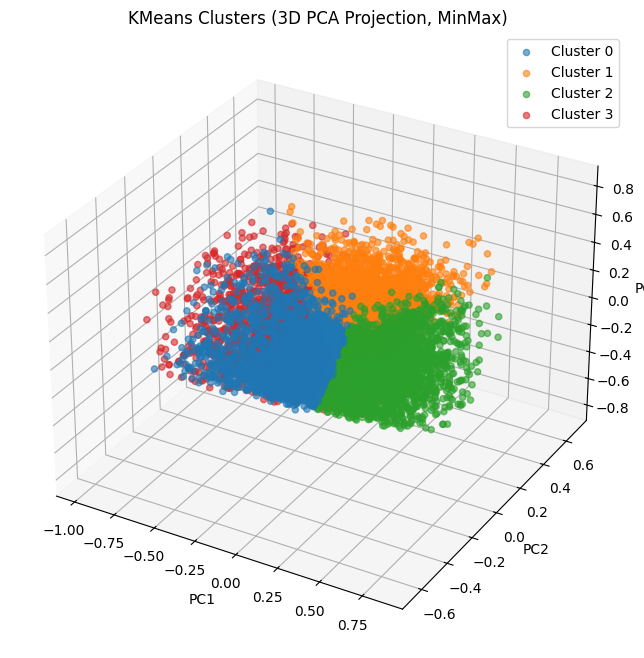

In [476]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # needed for 3D plots even if unused
import numpy as np

# PCA to 3 dimensions
pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_minmax)

# 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

for cluster in range(kmeans.n_clusters):
    ax.scatter(
        X_pca_3d[kmeans_clusters_minmax == cluster, 0],
        X_pca_3d[kmeans_clusters_minmax == cluster, 1],
        X_pca_3d[kmeans_clusters_minmax == cluster, 2],
        label=f'Cluster {cluster}',
        s=20,
        alpha=0.6
    )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('KMeans Clusters (3D PCA Projection, MinMax)')
ax.legend()

plt.show()


### Evaluation

In [477]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_zscore, clusters_zscore)
print(f'Silhouette Score (Zscore): {score:.3f}')


Silhouette Score (Zscore): 0.187


In [478]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_minmax, kmeans_clusters_minmax)
print(f'Silhouette Score (MinMax): {score:.3f}')


Silhouette Score (MinMax): 0.182


See which are the features that were most important for the clustering

In [479]:
# Get cluster centroids in scaled space
centroids = kmeans.cluster_centers_

# Create a DataFrame for easier reading
centroids_df = pd.DataFrame(centroids, columns=X.columns)

# Compute variance of each column across cluster centers
feature_importance = centroids_df.var(axis=0).sort_values(ascending=False)

print("Feature importance based on centroid variance:")
print(feature_importance)


Feature importance based on centroid variance:
popularity             0.023847
centroid               0.021518
rolloff                0.019041
aggressiveness         0.018159
spectral_complexity    0.017358
loudness               0.014899
dtype: float64


In [480]:
centroids_df


,centroid,loudness,spectral_complexity,rolloff,popularity,aggressiveness
0,0.507111,0.324500,0.388222,0.603015,0.221287,0.452529
1,0.521950,0.573587,0.524522,0.562903,0.559329,0.558738
2,0.673296,0.592255,0.677968,0.691251,0.245322,0.648104
3,0.315423,0.497974,0.414494,0.364755,0.364801,0.336161
